---
# Extracting twiss parameters (linear normal form)
---

Let's start by building a simple line (coupled, with a small sextupole to include non-linearities)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


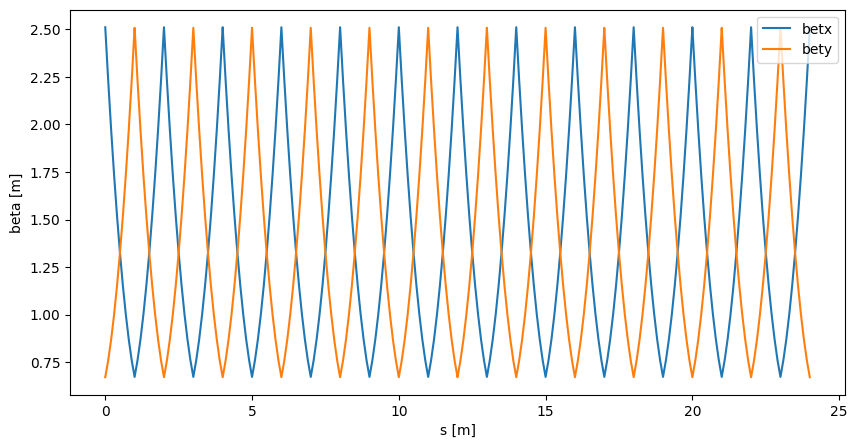

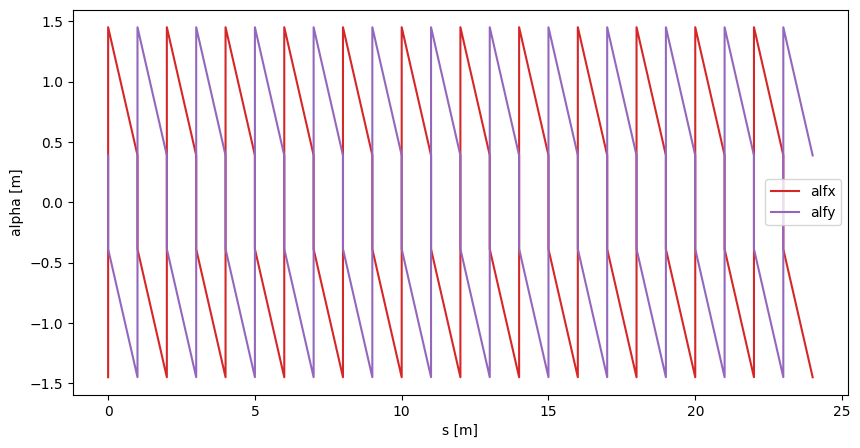

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import nafflib
import pytori as pt
import pytori.plotting as ptplt

import xtrack as xt
import xobjects as xo


# CELL parameters
#-----------------------
L       = 1                 #-- drift length
k       = 2/np.sqrt(3)      #-- focusing strength
dk      = 0.001*k           #-- to split x-y tunes
supP    = 12                 #-- superperiods
divs    = 10                   #-- drift divisions (for visualization)
#-----------------------


# ELEMENTS
#=========================================================================================
elements = {}
rot = 30
c_rot, s_rot = np.cos(2*np.deg2rad(rot)), np.sin(2*np.deg2rad(rot))

for n in range(supP):
    cell = {
            f'entry.{n}'        : xt.Marker(),
            # f'QF.{n}'           : xt.Multipole(knl=[0,k],ksl=[0,0],length=0),
            f'QF.{n}'           :xt.Multipole(knl=[0,(k+0)*c_rot,k/100],ksl=[0,(k+0)*s_rot],length=0),
            **{f'O1.{n}.{i}'    : xt.Drift(length=L/divs) for i in range(divs)},
            # f'QD.{n}'           : xt.Multipole(knl=[0,-(k+dk)],ksl=[0,0],length=0),
            f'QD.{n}'           :xt.Multipole(knl=[0,-(k+dk)*c_rot],ksl=[0,-(k+dk)*s_rot],length=0),
            **{f'O2.{n}.{i}'    : xt.Drift(length=L/divs) for i in range(divs)},
        }
    elements.update(cell)
#=========================================================================================

# BEAM & XSUITE LINE
#=========================================================================================
nrj             = 7000e9
particle_ref    = xt.Particles(p0c=nrj, q0=1, mass0=xt.PROTON_MASS_EV)
context         = xo.ContextCpu(omp_num_threads='auto')
nemitt_x        = 2.5e-6
nemitt_y        = 2.5e-6
gemitt_x        = 1 if nemitt_x is None else ( nemitt_x / particle_ref.beta0[0] / particle_ref.gamma0[0])
gemitt_y        = 1 if nemitt_y is None else ( nemitt_y / particle_ref.beta0[0] / particle_ref.gamma0[0])
#-----------------------------------------------------------------------------------------
line = xt.Line(elements=elements)
line.particle_ref = particle_ref
line.build_tracker(_context=context)
line.freeze_longitudinal(True)
twiss       = line.twiss4d()
#=========================================================================================


plt.figure(figsize=(10,5))
plt.plot(twiss.s, twiss.betx, label='betx')
plt.plot(twiss.s, twiss.bety, label='bety')
plt.xlabel('s [m]')
plt.ylabel('beta [m]')
plt.legend()


plt.figure(figsize=(10,5))
plt.plot(twiss.s, twiss.alfx, label='alfx',color='C3')
plt.plot(twiss.s, twiss.alfy, label='alfy',color='C4')
plt.xlabel('s [m]')
plt.ylabel('alpha [m]')
plt.legend()

#### Naturally, xsuite can twiss (tracking-based twiss)

In [2]:
import time
import sympy as sp

start = time.perf_counter()
#------------
twiss       = line.twiss(method='4d')
#------------
elapsed = time.perf_counter() - start
print(f"XSUITE twiss (all obs. points): {elapsed:.6f} s")

display(sp.Matrix(twiss.W_matrix[0][:4,:4]))

XSUITE twiss (all obs. points): 0.023029 s


Matrix([
[   1.5845906032761, 1.94056381026105e-16,  0.472953878440962, -3.33529956210712e-14],
[ 0.914863811356784,    0.473308372805815, -0.273060049032146,     0.528592768546679],
[-0.914863811356787, 3.31539877006878e-14,  0.819180147096494,  1.00320634506678e-16],
[-0.528196867758738,   -0.273264716449136, -0.472953878440948,     0.915549531636375]])

#### But pytori can also do it via a linear normal form (see P. Belanger's thesis).
1. We first find the linear part of the map in the form of U-V matrices 
2. We then extract, normarlize, sort, and regauge the eigentunes and eigenvectors
3. This can be used to build back the same W-matrix as xsuite


In [3]:
import time
import sympy as sp

start = time.perf_counter()
#------------
U,V     = pt.twiss.line_to_UV(line,method='4d')
Qvec,T  = pt.twiss.UV_to_QT(U,V)
W_matrix= pt.twiss.T_to_W(T)
#------------
elapsed = time.perf_counter() - start
print(f"pytori twiss (start of line only): {elapsed:.6f} s")

display(sp.Matrix(W_matrix))

pytori twiss (start of line only): 0.036348 s


Matrix([
[  1.58459060327606,                  0.0,  0.472953878440927,     1.57346358165e-13],
[ 0.914863811356854,    0.473308372805855, -0.273060049032261,      0.52859276854672],
[-0.914863811356843, -1.2356782264078e-13,  0.819180147096517, -2.77555756156289e-17],
[-0.528196867758557,   -0.273264716449158, -0.472953878441004,     0.915549531636285]])

#### And like in other examples, we can use this to build a matched torus 
(the eigensolution to the linear problem)

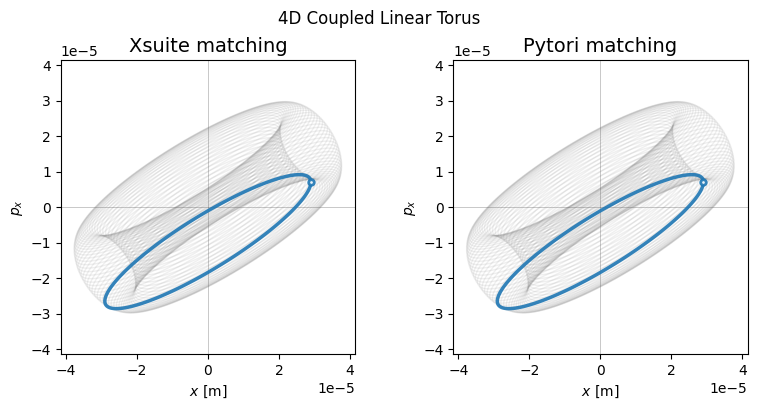

In [4]:
# Constructing matched torus from W-matrix (2D here)
x_sig  = 1
y_sig  = 1
nemitt_x = 2.5e-6
nemitt_y = 2.5e-6
xsuite_torus = pt.Torus.linear_match(I=[(x_sig**2)/2,(y_sig**2)/2],
                                        W_matrix=twiss.W_matrix[0],
                                        nemitt_x=nemitt_x, 
                                        nemitt_y=nemitt_y,
                                        particle_on_co=twiss.particle_on_co)

pytori_torus = pt.Torus.linear_match(I=[(x_sig**2)/2,(y_sig**2)/2],
                                        W_matrix=W_matrix,
                                        nemitt_x=nemitt_x, 
                                        nemitt_y=nemitt_y,
                                        particle_on_co=twiss.particle_on_co)

# Plotting

T_fixed =  {    'Tx':np.linspace(0,2*np.pi,500),
                'Ty':np.pi/2}
fig, axes = plt.subplots(1, 2, figsize=(8,4))
plt.suptitle('4D Coupled Linear Torus')
for ax,label,torus in zip(axes,['Xsuite','pytori'],[xsuite_torus,pytori_torus]):

    plt.sca(ax)
    plt.title(f'{label.capitalize()} matching',fontsize=14)

    Psi = torus.copy()


    # TORUS SHADOW, plotting all possible angle values
    #=======================================================
    T_loop = np.linspace(0,2*np.pi,100)
    T_vals = np.linspace(0,2*np.pi,70)
    for T0 in T_vals[:-1]:
        ptplt.loop(Psi,proj='x',Tx=T_loop,Ty=T0,edgecolor='dimgrey',alpha=0.1,lw=1)
    #=======================================================

    # Plotting a specific loop
    #=======================================================
    ptplt.loop(Psi,proj='x',**T_fixed,edgecolor='C0',alpha=0.9,lw=2.5)
    plt.plot(Psi.X(0,Ty=np.pi/2),Psi.PX(0,Ty=np.pi/2),'o',ms=4,alpha=0.9,mec='C0',mew=2,color='w',zorder=10)
        

    plt.axhline(0,color='k',ls='-',alpha=0.3,lw=0.5,zorder=-10)
    plt.axvline(0,color='k',ls='-',alpha=0.3,lw=0.5,zorder=-10)

    plt.axis('equal')
    plt.gca().set_box_aspect(1) 
    plt.xlabel(r'$x\ [\mathrm{m}]$');
    plt.ylabel(r'$p_x$');


 
plt.tight_layout()